# 股票多因子建模与投资前景评价：Stagewise 主线报告

本报告围绕课程作业要求组织：宏微观变量融合、200+ 综合因子、移动窗口前向分步回归变量选择、熵权-PROMETHEE 投资前景值、13 级评级和 Top-K 组合绩效检验。

In [11]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path('.')
OUT = ROOT / 'outputs'
FIG = ROOT / 'figures'

# 防止中文乱码：CSV 使用 utf-8-sig，matplotlib 优先使用 Windows 常见中文字体。
pd.set_option('display.unicode.east_asian_width', True)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def read_csv(name):
    return pd.read_csv(OUT / name, encoding='utf-8-sig')

def show_fig(name, width=900):
    path = FIG / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'缺少图表：`{path}`'))

## 1. 项目背景与作业要求

作业要求以个股财务、估值、成长、现金流、规模因子和宏观因子构造宏微观综合变量，并用变量选择方法服务预测与投资评价。本文将主线重构为：数据审计与预处理、200+ 综合因子、移动窗口前向分步回归、PROMETHEE 投资前景值、Hybrid Score、13 级评级、Top-K 回测和收益风险检验。

## 2. 数据来源与数据审计

个股数据按季度 sheet 组织，`月平均收益率` 已确认是下一期收益标签，本文命名为 `future_return_1q`，不做二次 shift。收益类字段、标签、股票代码、名称、季度索引和其他 meta 字段不进入模型特征。

作业说明中提到 12 个宏观因子，但实际提供的宏观因子数据文件中，仅能识别 11 个具名宏观变量。由于第 12 个宏观变量缺少字段名、定义和可观测数据，本文不进行主观补造，而采用 11 个可验证宏观因子参与后续建模与分析。

In [12]:
audit = json.loads((OUT / 'stagewise_data_audit_summary.json').read_text(encoding='utf-8'))
display(pd.Series(audit, name='value').to_frame())
display(read_csv('stagewise_factor_audit.csv').head(30))

,value
generated_at,2026-05-23T00:08:44
stock_source,outputs\stock_panel.parquet
macro_source,outputs\macro_quarterly_aligned.csv
stock_rows,42720
quarter_count,30
stock_factor_count,21
macro_factor_count,11
composite_factor_count,231
label_definition,future_return_1q = 原始月平均收益率，不做二次 shift...
macro_factor_note,作业说明中提到 12 个宏观因子，但实际提供文件仅能识别 11 个具名宏观变量。...


,column,included_as_stock_factor,reason
0,quarter_idx,False,meta_or_explicit_return_field
1,sheet_name,False,meta_or_explicit_return_field
2,row_id_raw,False,meta_or_explicit_return_field
3,证券代码,False,meta_or_explicit_return_field
4,证券名称,False,meta_or_explicit_return_field
5,净资产收益率(TTM),True,base_stock_factor
6,总资产报酬率(TTM),True,base_stock_factor
7,销售净利率(TTM),True,base_stock_factor
8,销售毛利率(TTM),True,base_stock_factor
9,经营活动净收益/利润总额(TTM),True,base_stock_factor


## 3. 数据预处理

缺失值填补、1%/99% winsorize 和标准化参数仅在训练期 `quarter_idx=1-21` 拟合，然后应用于验证期 `22-25` 和测试期 `26-30`。时间顺序不随机打乱，横截面排序和评分均按季度独立计算。

In [13]:
display(read_csv('stagewise_preprocess_params.csv').head())
panel_cols = pd.read_parquet(OUT / 'model_ready_stagewise_panel.parquet').columns
print('model_ready_stagewise_panel columns:', len(panel_cols))

,source_column,standardized_column,median_train,winsor_p01_train,winsor_p99_train,mean_train,std_train,group
0,净资产收益率(TTM),std_stock_净资产收益率_TTM,5.69790,-101.763182,36.522870,4.202853,16.787165,stock_factor
1,总资产报酬率(TTM),std_stock_总资产报酬率_TTM,4.69925,-32.931237,25.194382,4.732211,7.742157,stock_factor
2,销售净利率(TTM),std_stock_销售净利率_TTM,5.74100,-121.404432,42.394838,4.007638,20.013968,stock_factor
3,销售毛利率(TTM),std_stock_销售毛利率_TTM,24.36820,-2.086038,80.237981,27.784324,16.863215,stock_factor
4,经营活动净收益/利润总额(TTM),std_stock_经营活动净收益_利润总额_TTM,78.90800,-775.691300,123.984008,45.995461,117.919952,stock_factor


model_ready_stagewise_panel columns: 304


## 4. 200+ 宏微观综合因子构造

作业要求中的 276 个综合因子来自 `23 × 12` 的理论设定。实际数据审计后，由于宏观因子仅 11 个可验证变量，且部分个股字段属于收益类字段，本文采用可复现、无泄漏的综合因子口径，构造 `21 × 11 = 231` 个宏微观交互综合因子。

综合因子公式：`composite_{stock_factor_i}_x_{macro_j} = standardized_stock_factor_i × standardized_macro_j`。

,composite_feature,stock_factor,macro_factor,stock_standardized_column,macro_standardized_column,formula,is_composite
0,composite_净资产收益率_TTM_x_bm,净资产收益率(TTM),bm,std_stock_净资产收益率_TTM,std_macro_bm,std_stock_净资产收益率_TTM * std_macro_bm,True
1,composite_净资产收益率_TTM_x_de,净资产收益率(TTM),de,std_stock_净资产收益率_TTM,std_macro_de,std_stock_净资产收益率_TTM * std_macro_de,True
2,composite_净资产收益率_TTM_x_dp,净资产收益率(TTM),dp,std_stock_净资产收益率_TTM,std_macro_dp,std_stock_净资产收益率_TTM * std_macro_dp,True
3,composite_净资产收益率_TTM_x_ep,净资产收益率(TTM),ep,std_stock_净资产收益率_TTM,std_macro_ep,std_stock_净资产收益率_TTM * std_macro_ep,True
4,composite_净资产收益率_TTM_x_infl,净资产收益率(TTM),infl,std_stock_净资产收益率_TTM,std_macro_infl,std_stock_净资产收益率_TTM * std_macro_infl,True


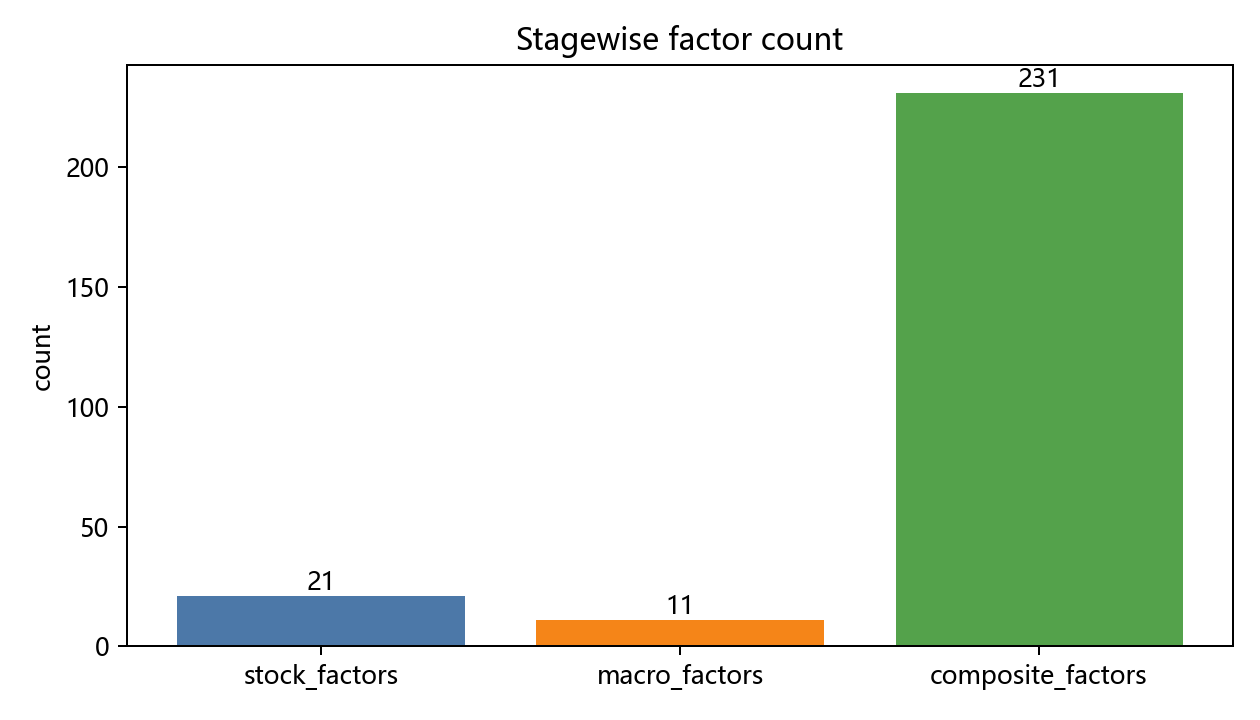

In [14]:
display(read_csv('composite_factor_list.csv').head())
show_fig('fig_composite_factor_count.png', 760)

## 5. 移动窗口前向分步回归变量选择

对每一个预测季度，用此前 12 个季度作为训练窗口，在 231 个综合因子中执行前向分步回归。每一步选择与当前残差相关性最高且能改善 SSE 的变量，重新拟合 OLS 并更新残差。验证期用于观察参数设置表现，测试期只做最终 holdout 检验。

,feature,selected_count,avg_abs_coefficient,first_selected_avg_step,stock_factor,macro_factor,is_composite,feature_group
0,composite_市净率PB_LF_x_bm,12,2.037053,1.750000,市净率PB(LF),bm,True,macro_micro_composite
1,composite_销售毛利率_TTM_x_infl,11,1.882543,2.636364,销售毛利率(TTM),infl,True,macro_micro_composite
2,composite_净资产收益率_1年_增长率_x_bm,11,1.412865,5.818182,净资产收益率(1年，增长率),bm,True,macro_micro_composite
3,composite_总市值_证监会算法_x_bm,10,2.197802,3.400000,总市值(证监会算法),bm,True,macro_micro_composite
4,composite_市净率PB_LF_x_svar,9,2.405304,3.444444,市净率PB(LF),svar,True,macro_micro_composite
5,composite_营业收入_1年_增长率_x_itgr,8,1.362971,4.375000,营业收入(1年，增长率),itgr,True,macro_micro_composite
6,composite_市净率PB_LF_x_ep,8,1.281391,4.625000,市净率PB(LF),ep,True,macro_micro_composite
7,composite_营业外收支净额_利润总额_TTM_x_tms,8,0.895762,10.250000,营业外收支净额/利润总额(TTM),tms,True,macro_micro_composite
8,composite_市净率PB_LF_x_infl,6,2.625538,7.666667,市净率PB(LF),infl,True,macro_micro_composite
9,composite_市净率PB_LF_x_de,6,1.764624,5.333333,市净率PB(LF),de,True,macro_micro_composite


,quarter_idx,split,rankic,n_stocks,selected_feature_count
0,13,train,-0.028160,1424,15
1,14,train,-0.153677,1424,15
2,15,train,-0.058808,1424,15
3,16,train,0.095242,1424,15
4,17,train,0.179707,1424,15
5,18,train,-0.031347,1424,15
6,19,train,0.106952,1424,15
7,20,train,0.028864,1424,15
8,21,train,0.011298,1424,15
9,22,valid,-0.044116,1424,15


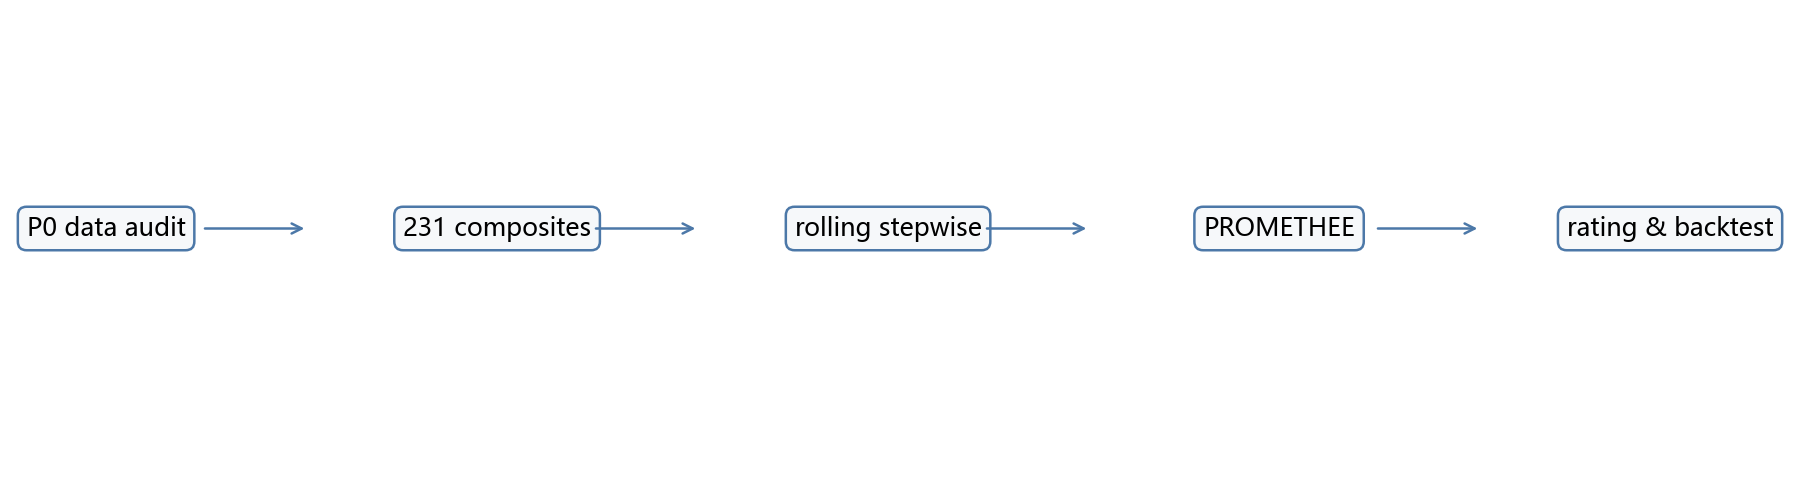

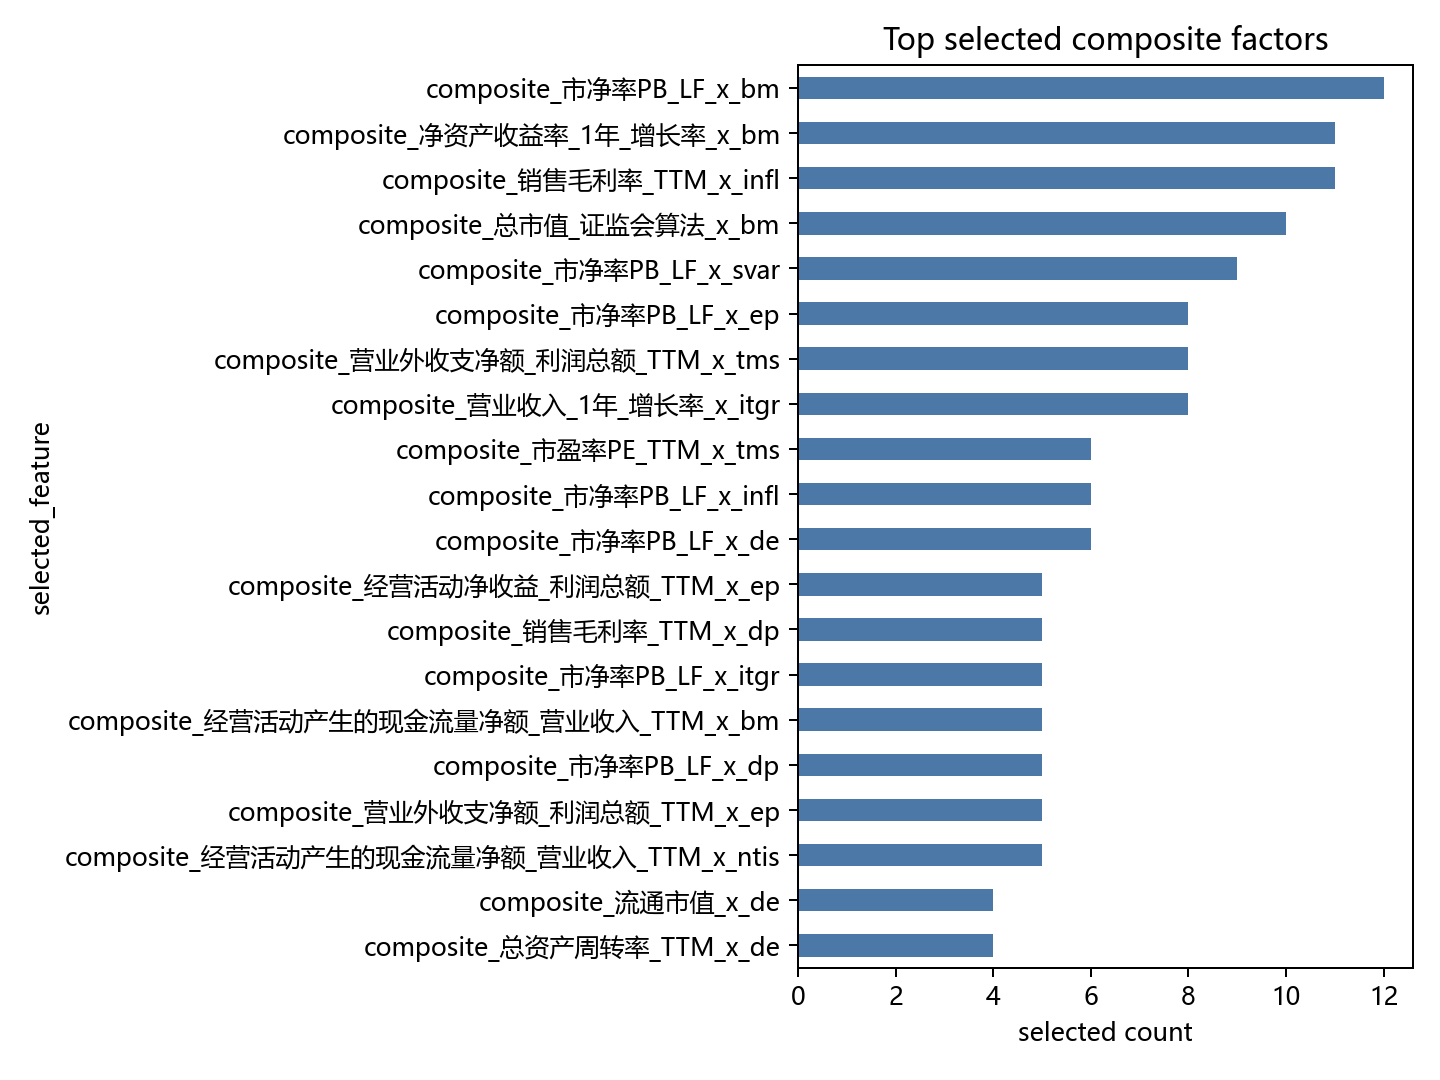

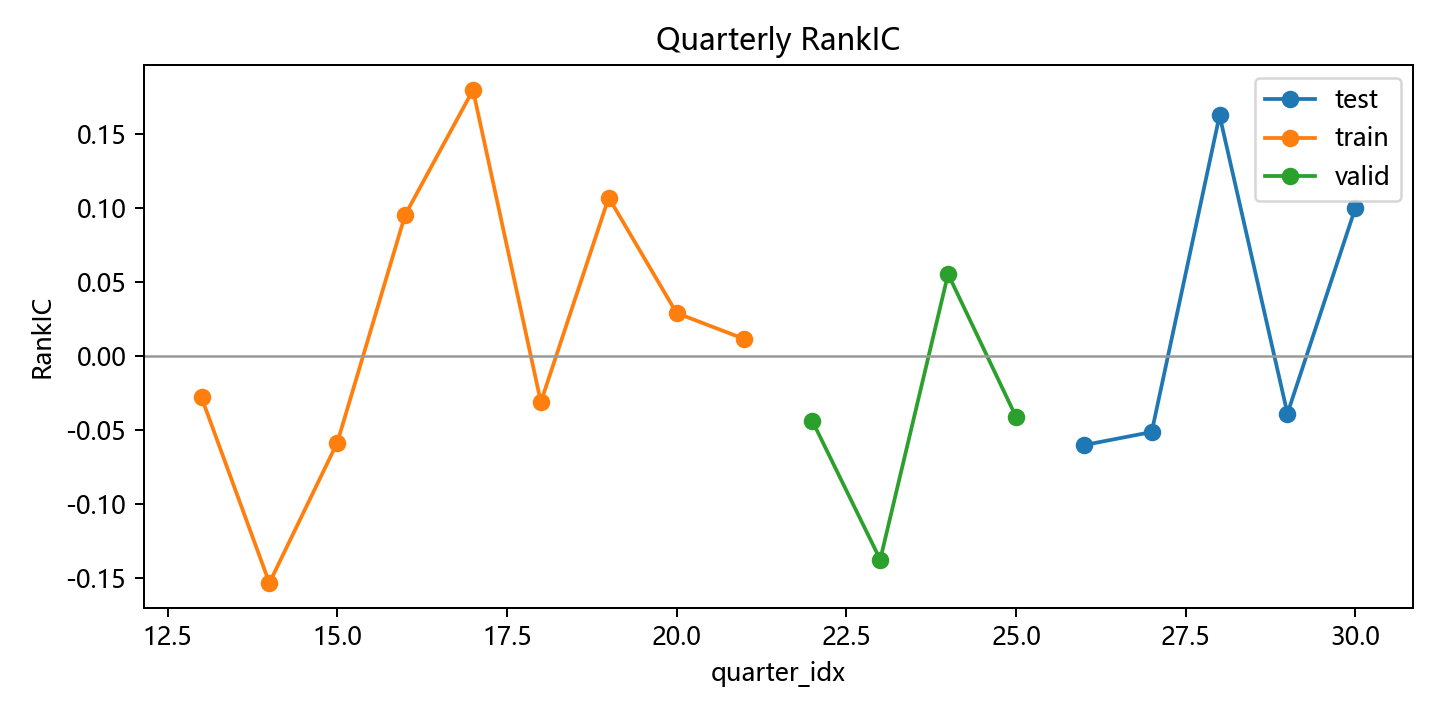

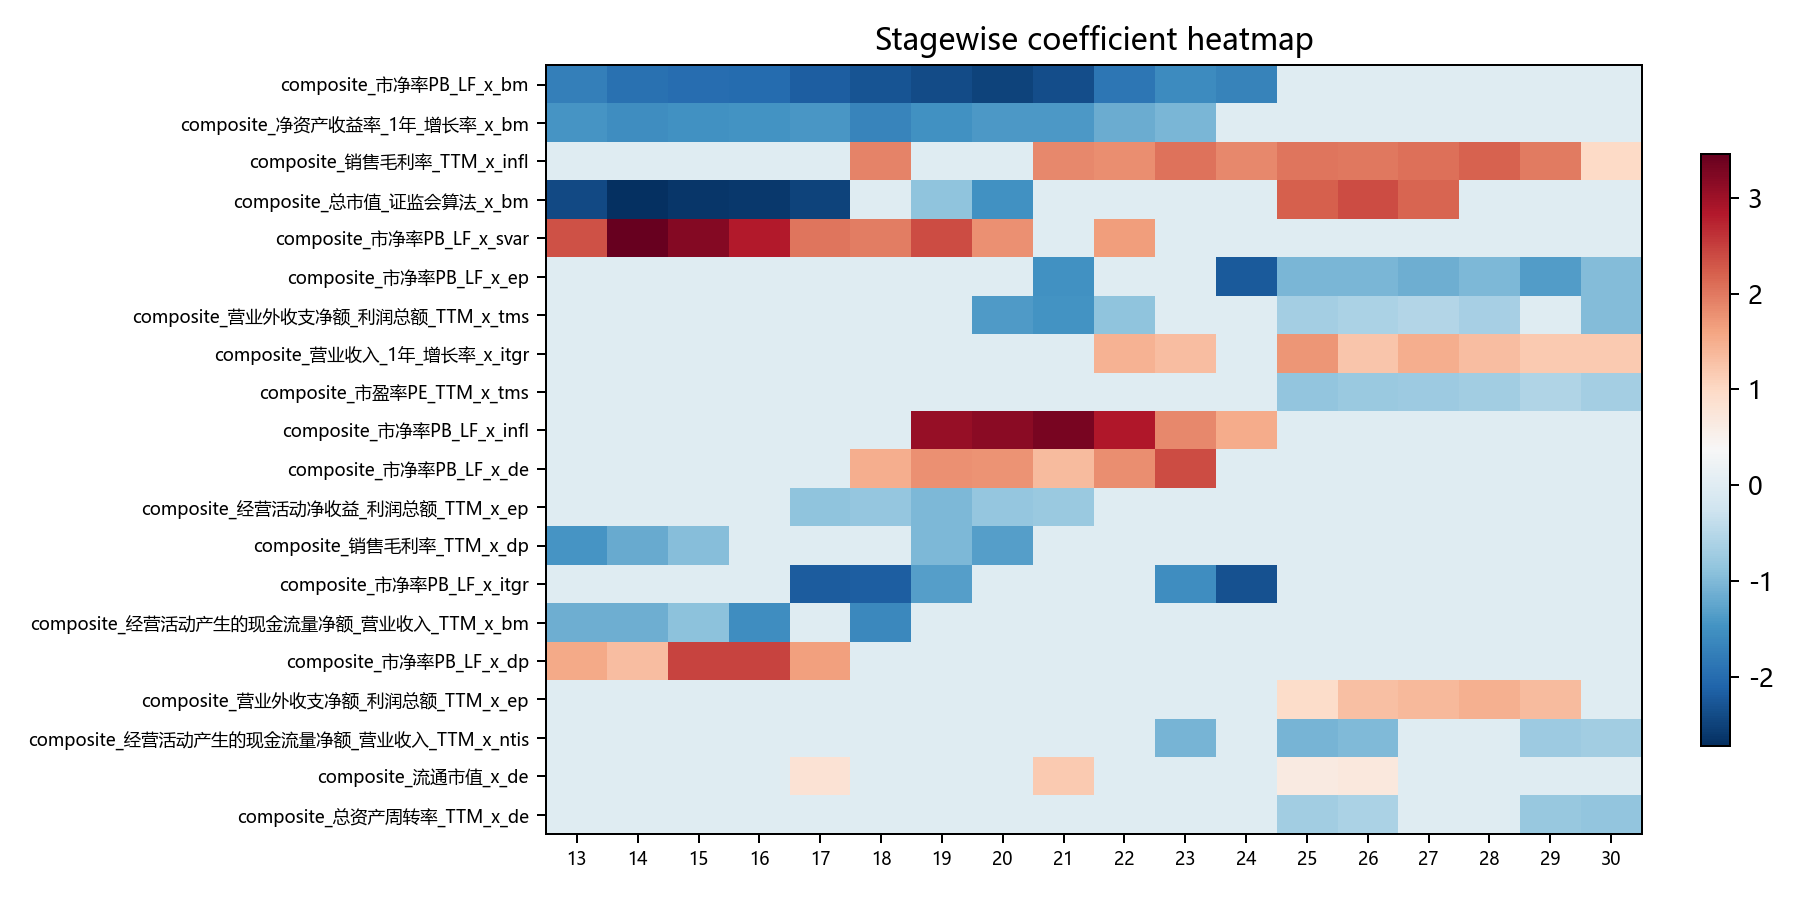

In [15]:
+selected = read_csv('stagewise_selected_features_by_quarter.csv')
freq = read_csv('stagewise_feature_frequency.csv')
rankic = read_csv('stagewise_quarterly_rankic.csv')
display(freq.head(20))
display(rankic)
show_fig('fig_stagewise_pipeline.png')
show_fig('fig_stagewise_top_feature_frequency.png')
show_fig('fig_stagewise_quarterly_rankic.png')
show_fig('fig_stagewise_coefficient_heatmap.png')

## 6. 预测排序结果

收益率预测本身噪声较高，低 R² 不应直接解释为方法失败。本文更关注 RankIC、季度内排序能力和组合回测表现。

In [16]:
display(read_csv('stagewise_model_summary.csv'))
display(read_csv('stagewise_prediction_panel.csv').head())

,split,metric,value
0,train,mse,584.308701
1,train,rmse,24.172478
2,train,mae,15.775681
3,train,r2,-0.099034
4,train,mean_rankic,0.016674
5,train,top10_avg_return,5.036638
6,train,top20_avg_return,5.912558
7,train,top30_avg_return,5.661473
8,valid,mse,830.410764
9,valid,rmse,28.816849


,quarter_idx,split,stock_id,stock_name,future_return_1q,stagewise_pred,stagewise_rank,stagewise_rank_pct,selected_feature_count,selected_features
0,13,train,000008.SZ,神州高铁,-18.185211,0.030525,475.0,0.667135,15,composite_总市值_证监会算法_x_bm;composite_市净率PB_LF_x_...
1,13,train,000012.SZ,南玻A,-16.486737,-2.620140,1144.0,0.197331,15,composite_总市值_证监会算法_x_bm;composite_市净率PB_LF_x_...
2,13,train,000016.SZ,深康佳A,-24.865832,-3.651151,1323.0,0.071629,15,composite_总市值_证监会算法_x_bm;composite_市净率PB_LF_x_...
3,13,train,000017.SZ,深中华A,-16.914498,24.416702,1.0,1.000000,15,composite_总市值_证监会算法_x_bm;composite_市净率PB_LF_x_...
4,13,train,000020.SZ,深华发A,-12.640000,15.425808,9.0,0.994382,15,composite_总市值_证监会算法_x_bm;composite_市净率PB_LF_x_...


## 7. 熵权-PROMETHEE 投资前景值

PROMETHEE 指标集来自当前季度滚动窗口中前向分步回归选出的因子，不使用 `future_return_1q`。无法明确经济方向的综合交互因子按分步回归系数符号确定正负方向，随后在季度内计算熵权、正流、负流和净流。

In [17]:
display(read_csv('entropy_weights_stagewise.csv').head(20))
display(read_csv('promethee_scores_stagewise.csv').head())

,quarter_idx,feature,entropy,weight,direction,coefficient_for_direction
0,13,composite_总市值_证监会算法_x_bm,0.997484,0.011194,negative,-2.403999
1,13,composite_市净率PB_LF_x_bm,0.998145,0.008253,negative,-1.737892
2,13,composite_市净率PB_LF_x_svar,0.947596,0.233126,positive,2.343872
3,13,composite_净资产收益率_1年_增长率_x_bm,0.996634,0.014974,negative,-1.449574
4,13,composite_市净率PB_LF_x_ntis,0.947596,0.233126,negative,-2.726063
5,13,composite_市净率PB_LF_x_dp,0.998145,0.008253,positive,1.545624
6,13,composite_销售毛利率_TTM_x_dp,0.978394,0.096117,negative,-1.439303
7,13,composite_流通市值_x_itgr,0.997493,0.011152,positive,1.335412
8,13,composite_经营活动产生的现金流量净额_营业收入_TTM_x_bm...,0.992156,0.034895,negative,-1.121940
9,13,composite_营业外收支净额_利润总额_TTM_x_infl,0.999156,0.003754,negative,-1.069765


,quarter_idx,stock_id,stock_name,promethee_phi_plus,promethee_phi_minus,promethee_net_flow,promethee_rank
0,13,000008.SZ,神州高铁,0.051234,0.051486,-0.000253,515.0
1,13,000012.SZ,南玻A,0.014716,0.070580,-0.055864,1173.0
2,13,000016.SZ,深康佳A,0.019736,0.079611,-0.059875,1212.0
3,13,000017.SZ,深中华A,0.658464,0.045096,0.613367,6.0
4,13,000020.SZ,深华发A,0.277747,0.036200,0.241547,34.0


## 8. Hybrid Score 与 Top-K 选股

Hybrid Score 将 PROMETHEE 净流排序百分位和 stagewise 预测排序百分位融合。本文固定输出 pure stagewise、pure PROMETHEE、70/30、50/50、30/70，不根据测试期表现反向选择权重。由于未提供外部市场指数收益，本文以当期股票池等权平均收益作为横截面基准，用于计算相对收益、Alpha 和 Beta。

,quarter_idx,split,stock_id,stock_name,future_return_1q,stagewise_pred,promethee_net_flow,pure_stagewise_score,pure_promethee_score,hybrid_score_50_50,hybrid_score_30_70,hybrid_score_70_30
0,13,train,000008.SZ,神州高铁,-18.185211,0.030525,-0.000253,0.667135,0.639045,0.653090,0.658708,0.647472
1,13,train,000012.SZ,南玻A,-16.486737,-2.620140,-0.055864,0.197331,0.176966,0.187149,0.191222,0.183076
2,13,train,000016.SZ,深康佳A,-24.865832,-3.651151,-0.059875,0.071629,0.149579,0.110604,0.095014,0.126194
3,13,train,000017.SZ,深中华A,-16.914498,24.416702,0.613367,1.000000,0.996489,0.998244,0.998947,0.997542
4,13,train,000020.SZ,深华发A,-12.640000,15.425808,0.241547,0.994382,0.976826,0.985604,0.989115,0.982093


,split,strategy,period_count,holding_period_avg_return,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,alpha,beta,max_drawdown,win_rate,average_turnover
0,all,hybrid_score_30_70_top10,18,5.885604,1.297756,0.203067,0.329837,0.615658,0.026364,1.692311,-0.244301,0.611111,0.888889
1,all,hybrid_score_30_70_top20,18,3.478843,0.640195,0.116232,0.249121,0.466570,-0.018428,1.275601,-0.176431,0.555556,0.825000
2,all,hybrid_score_50_50_top10,18,5.319563,1.040249,0.171706,0.347796,0.493696,-0.003196,1.748315,-0.296849,0.555556,0.855556
3,all,hybrid_score_50_50_top20,18,4.182444,0.828194,0.143476,0.263210,0.545103,-0.002310,1.372952,-0.177828,0.555556,0.830556
4,all,hybrid_score_50_50_top30,18,4.066841,0.851864,0.146750,0.230386,0.636973,0.010641,1.230685,-0.129240,0.555556,0.807407
5,all,hybrid_score_70_30_top10,18,3.112640,0.498197,0.093995,0.271481,0.346230,-0.045852,1.379022,-0.260295,0.555556,0.816667
6,all,hybrid_score_70_30_top20,18,4.699871,0.981476,0.164119,0.274855,0.597113,0.009063,1.448427,-0.149520,0.555556,0.813889
7,all,pure_promethee_score_top10,18,1.902377,0.181911,0.037839,0.297807,0.127059,-0.095161,1.386297,-0.288427,0.500000,0.477778
8,all,pure_promethee_score_top20,18,3.722876,0.629345,0.114587,0.300240,0.381652,-0.031873,1.463459,-0.225791,0.444444,0.422222
9,all,pure_promethee_score_top30,18,3.897160,0.706473,0.126102,0.286148,0.440688,-0.014285,1.377515,-0.220024,0.500000,0.348148


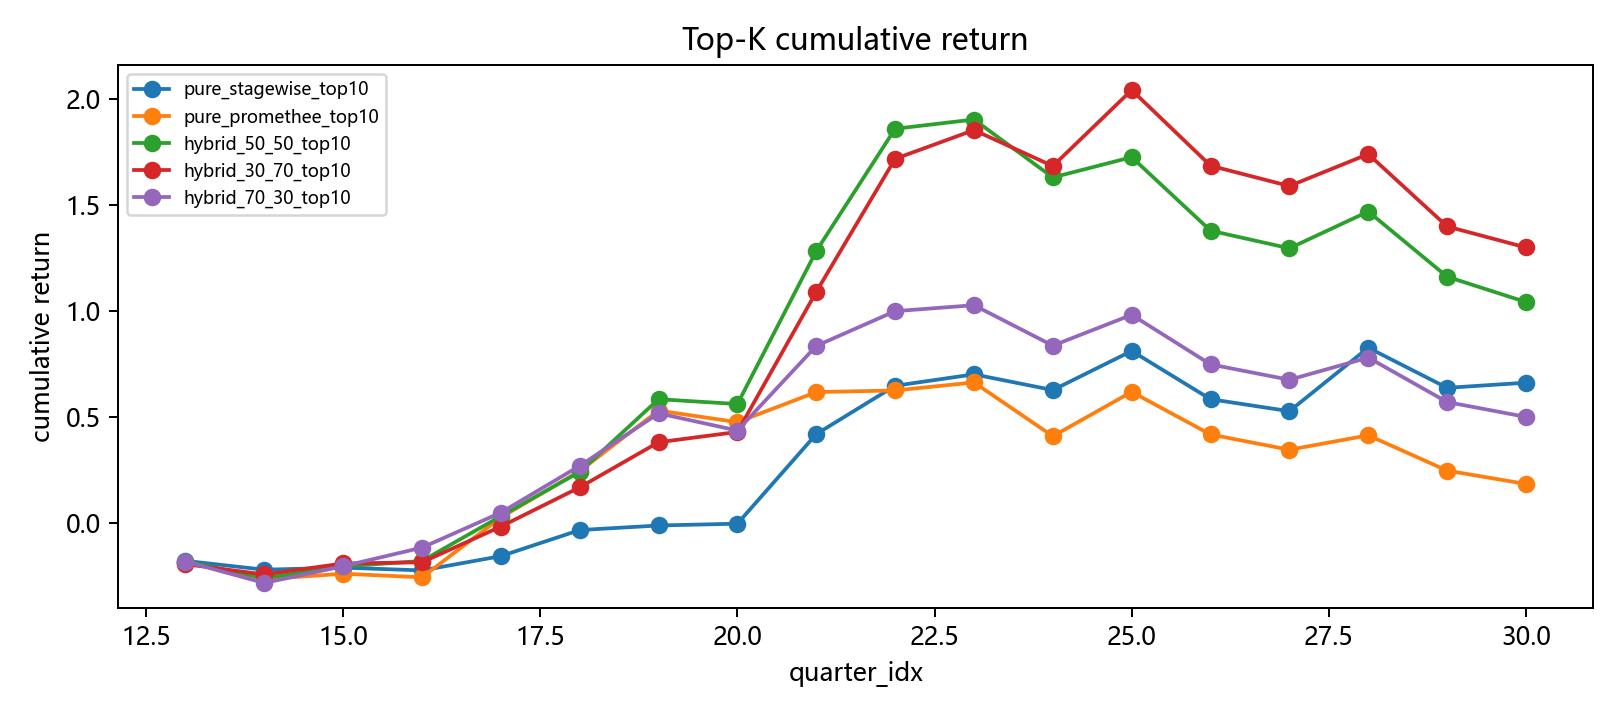

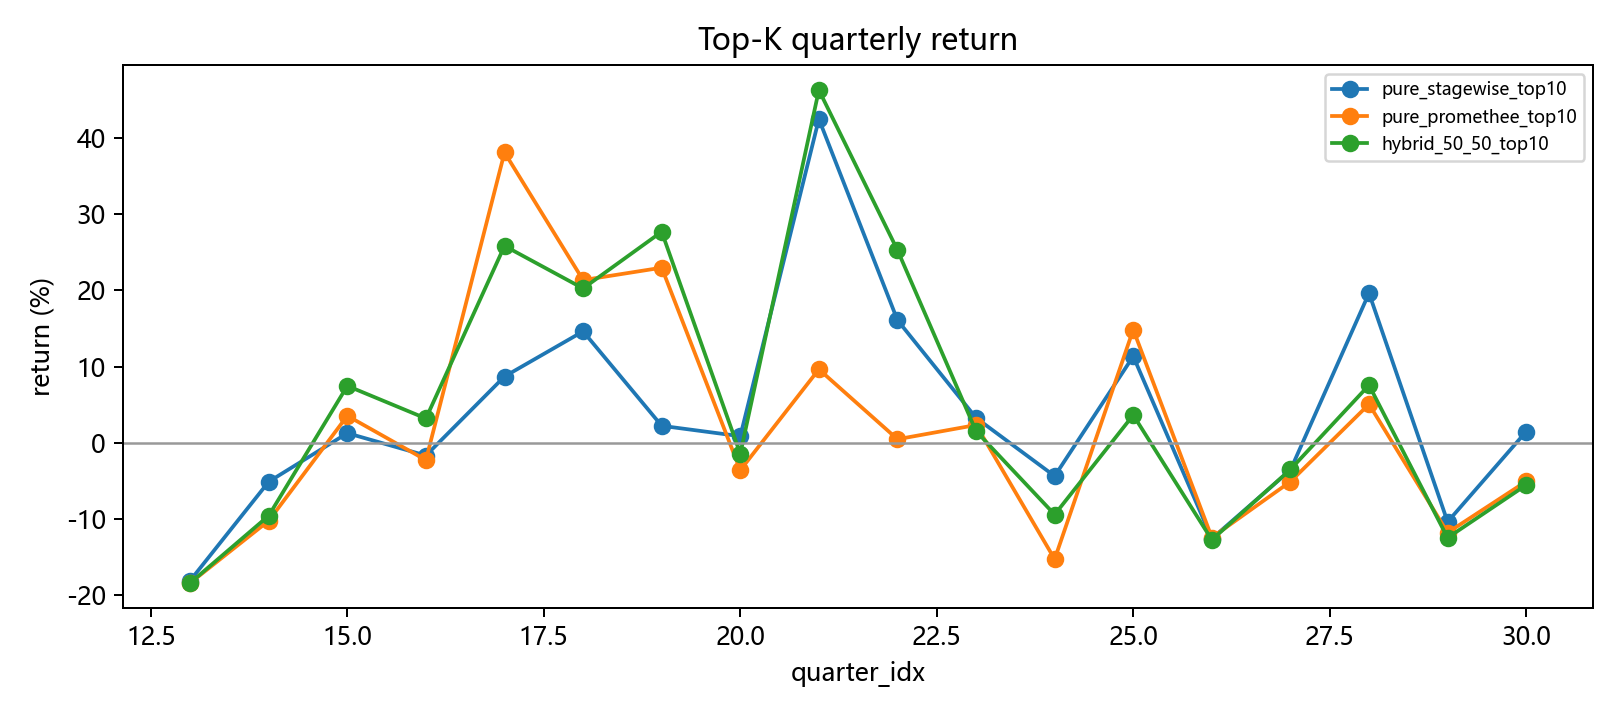

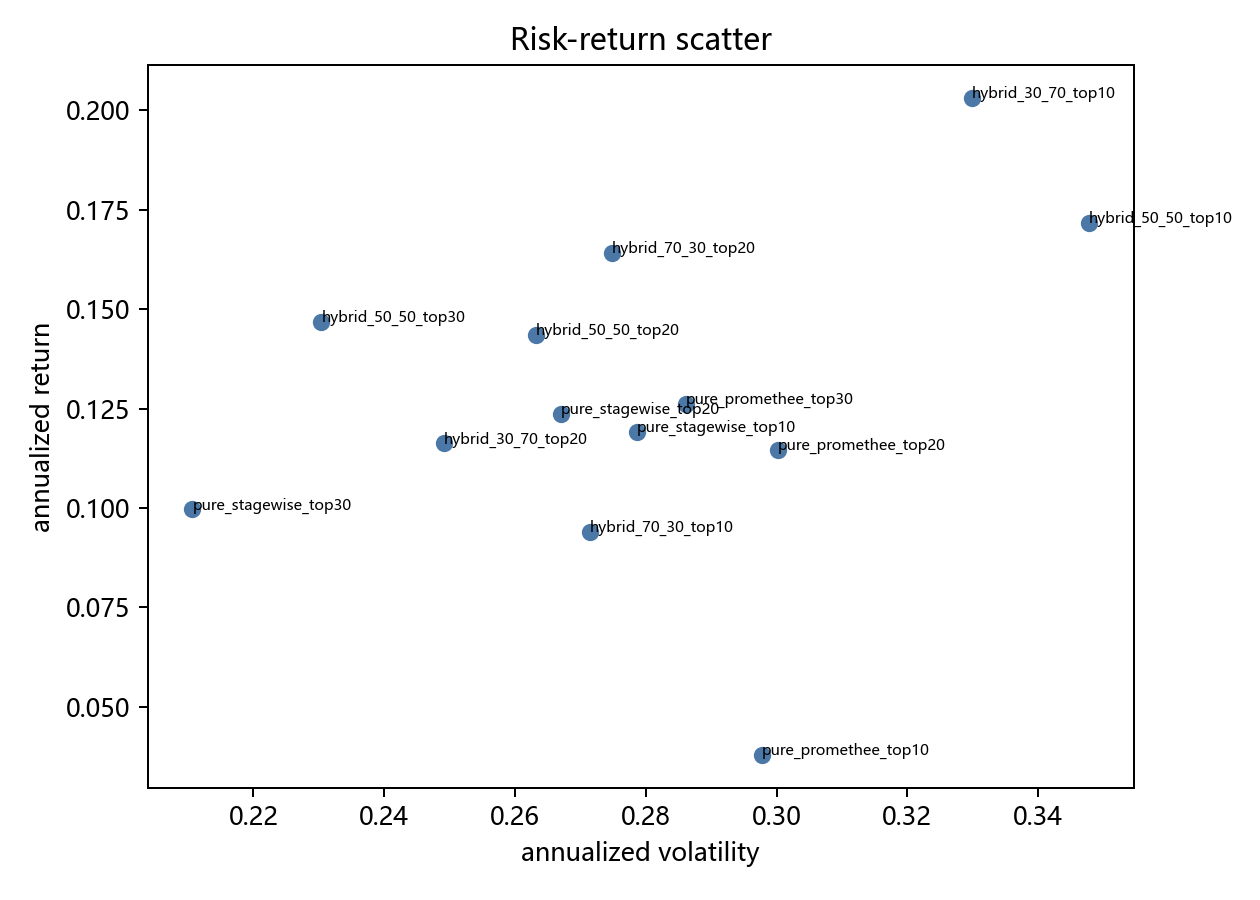

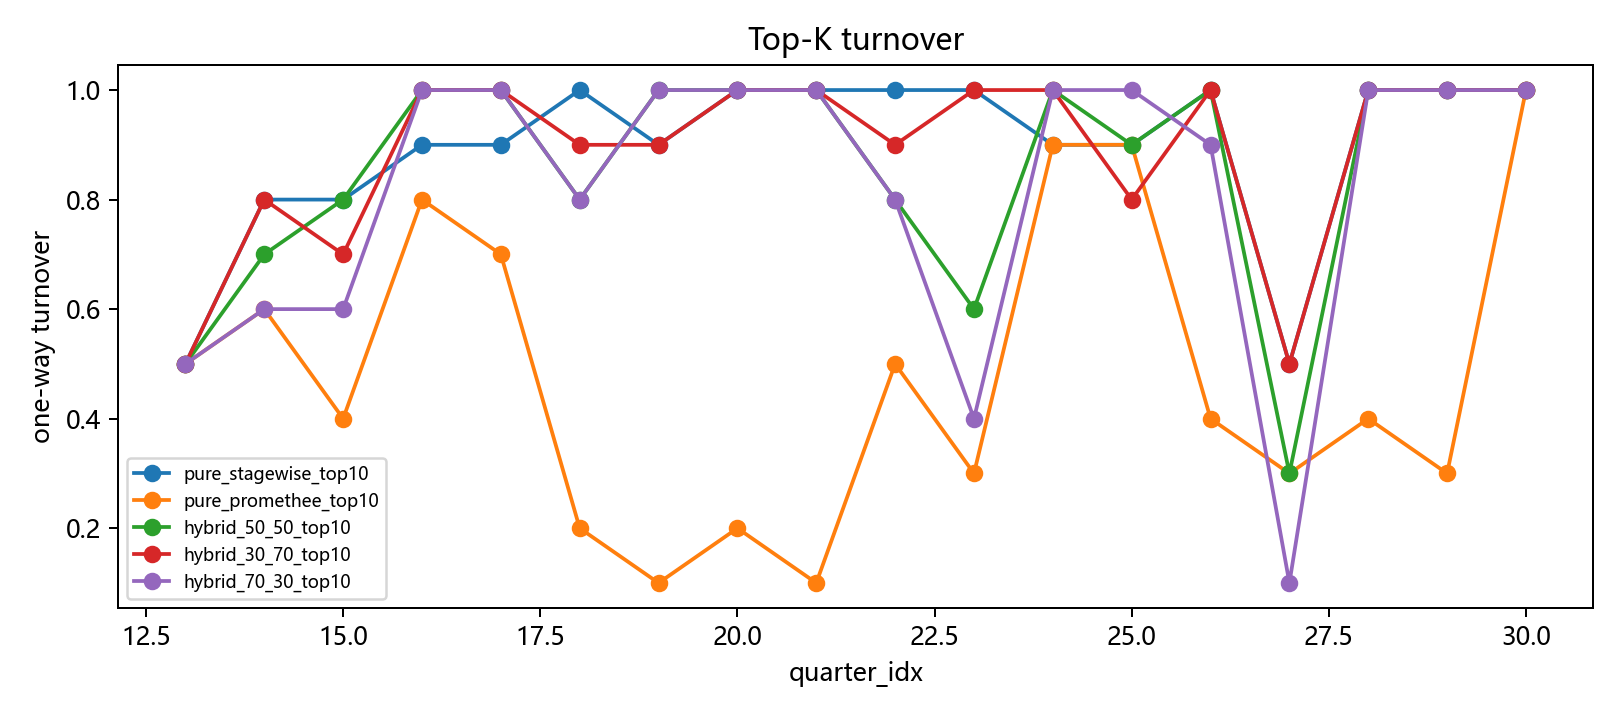

In [18]:
display(read_csv('hybrid_scores_stagewise.csv').head())
display(read_csv('topk_performance_metrics_stagewise.csv'))
show_fig('fig_topk_cumulative_return_stagewise.png')
show_fig('fig_topk_quarterly_return_stagewise.png')
show_fig('fig_topk_risk_return_scatter_stagewise.png')
show_fig('fig_turnover_stagewise.png')

### 补充可视化：策略表现诊断

![Top-K excess return heatmap](figures/fig_topk_excess_return_heatmap_stagewise.png)

![Strategy metric profile](figures/fig_strategy_metric_heatmap_stagewise.png)

![Stagewise vs PROMETHEE score agreement](figures/fig_score_agreement_scatter_stagewise.png)


## 9. 13 级评级与检验

基于 `hybrid_score_50_50` 在每个季度内从高到低分为 AAA 到 B 共 13 级。评级生成不使用未来收益，`future_return_1q` 仅用于事后检验各等级表现。评级不要求严格单调，但可作为候选池筛选工具。

,quarter_idx,split,stock_id,stock_name,rating,rating_rank_in_quarter,rating_score_source,hybrid_score_50_50,future_return_1q
0,13,train,600421.SH,华嵘控股,AAA,1,hybrid_score_50_50,0.999649,-29.113924
1,13,train,000017.SZ,深中华A,AAA,2,hybrid_score_50_50,0.998244,-16.914498
2,13,train,002248.SZ,华东数控,AAA,3,hybrid_score_50_50,0.998244,-7.321773
3,13,train,600610.SH,中毅达,AAA,4,hybrid_score_50_50,0.998244,-21.256039
4,13,train,600234.SH,*ST科新,AAA,5,hybrid_score_50_50,0.997893,-9.203980


,split,rating,avg_future_return,median_future_return,stock_count,positive_rate,rating_order
0,test,AAA,-1.877766,-2.562861,550,0.432727,0
1,test,AA+,-0.563604,-2.439056,550,0.443636,1
2,test,AA,2.366924,0.414508,545,0.508257,2
3,test,AA-,1.749347,-0.843612,550,0.472727,3
4,test,A+,-0.455556,-1.576577,545,0.455046,4
5,test,A,-1.008983,-2.025044,550,0.441818,5
6,test,A-,-0.108299,-1.239669,545,0.460550,6
7,test,BBB+,0.702729,-1.112971,550,0.454545,7
8,test,BBB,0.402037,-0.745156,545,0.473394,8
9,test,BBB-,0.074831,-0.776244,550,0.472727,9


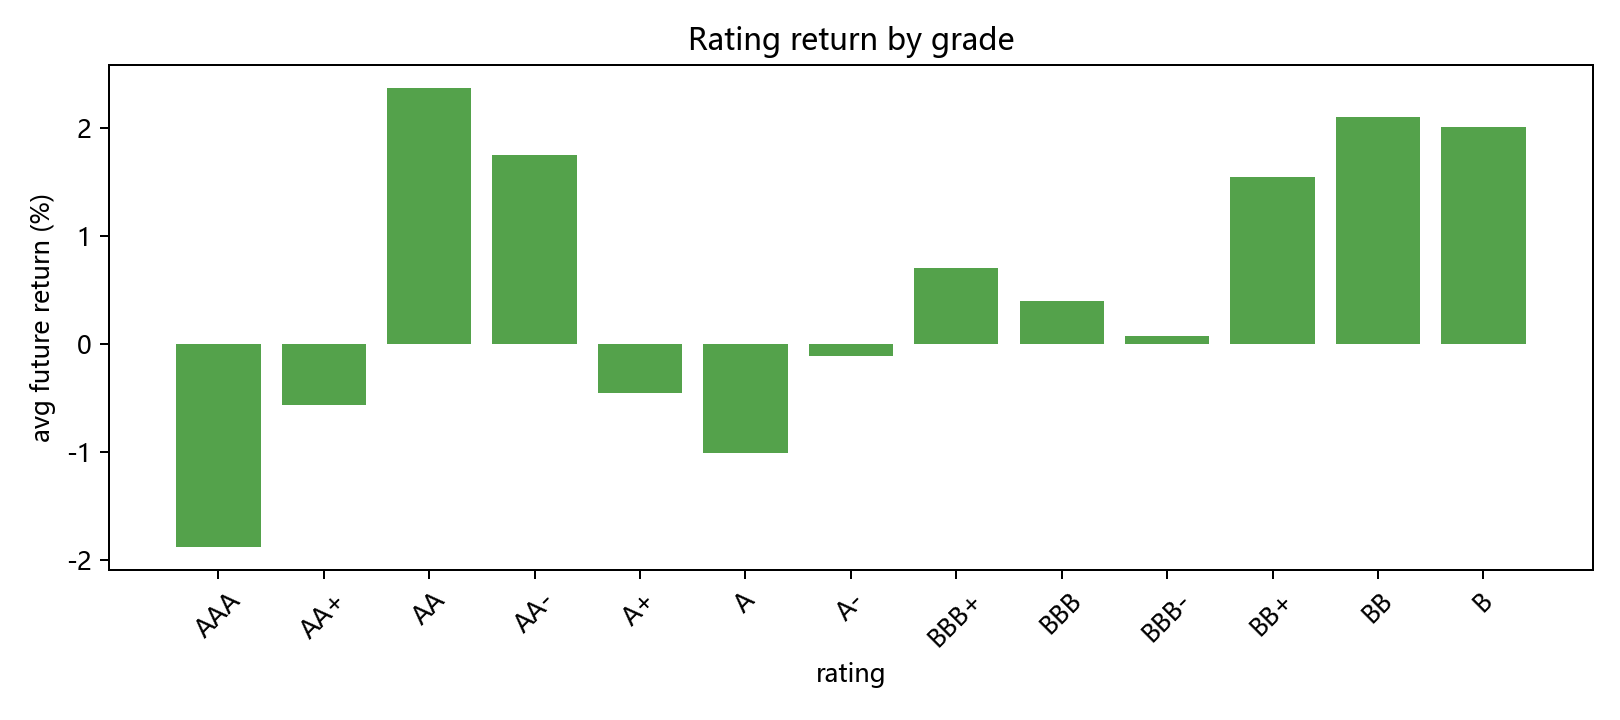

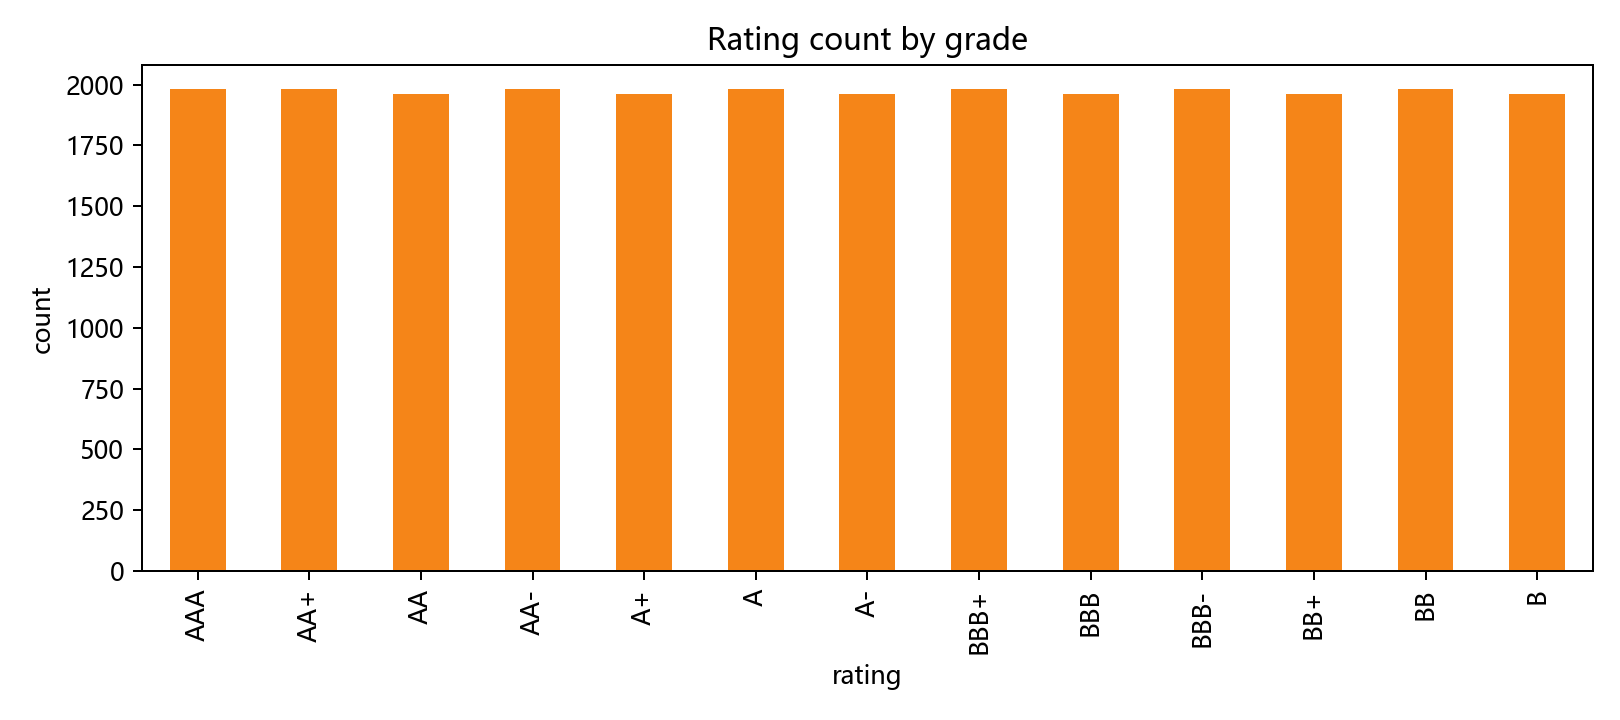

In [19]:
display(read_csv('rating_panel_stagewise.csv').head())
display(read_csv('rating_performance_stagewise.csv'))
show_fig('fig_rating_return_by_grade.png')
show_fig('fig_rating_count_by_grade.png')

### 补充可视化：评级分层诊断

![Rating positive rate by grade](figures/fig_rating_positive_rate_by_grade.png)

![Rating quarterly return heatmap](figures/fig_rating_quarterly_return_heatmap.png)


## 10. 综合绩效评价

绩效指标包括持有期平均收益率、累计收益率、年化收益率、年化波动率、Sharpe Ratio、Alpha、Beta、最大回撤、胜率、平均换手率、每季度持仓数量和每季度组合收益。

In [20]:
display(read_csv('topk_quarterly_returns_stagewise.csv').head(30))
display(read_csv('topk_holdings_stagewise.csv').head())

,quarter_idx,split,strategy,score_col,topk,portfolio_return,benchmark_return,excess_return,turnover,holding_count
0,13,train,pure_stagewise_score_top10,pure_stagewise_score,10,-18.084104,-7.914061,-10.170043,0.50,10
1,14,train,pure_stagewise_score_top10,pure_stagewise_score,10,-5.107674,-1.945783,-3.161891,0.80,10
2,15,train,pure_stagewise_score_top10,pure_stagewise_score,10,1.267130,5.373003,-4.105873,0.80,10
3,16,train,pure_stagewise_score_top10,pure_stagewise_score,10,-1.669890,-1.597084,-0.072805,0.90,10
4,17,train,pure_stagewise_score_top10,pure_stagewise_score,10,8.703689,8.620599,0.083090,0.90,10
5,18,train,pure_stagewise_score_top10,pure_stagewise_score,10,14.627083,13.312881,1.314203,1.00,10
6,19,train,pure_stagewise_score_top10,pure_stagewise_score,10,2.231241,4.809627,-2.578386,0.90,10
7,20,train,pure_stagewise_score_top10,pure_stagewise_score,10,0.867218,0.041700,0.825518,1.00,10
8,21,train,pure_stagewise_score_top10,pure_stagewise_score,10,42.495052,13.191846,29.303207,1.00,10
9,22,valid,pure_stagewise_score_top10,pure_stagewise_score,10,16.101211,9.158056,6.943155,1.00,10


,quarter_idx,split,stock_id,stock_name,future_return_1q,score,portfolio_rank,weight,strategy,score_col,topk
0,13,train,000017.SZ,深中华A,-16.914498,1.000000,1,0.1,pure_stagewise_score_top10,pure_stagewise_score,10
1,13,train,600421.SH,华嵘控股,-29.113924,0.999298,2,0.1,pure_stagewise_score_top10,pure_stagewise_score,10
2,13,train,600610.SH,中毅达,-21.256039,0.998596,3,0.1,pure_stagewise_score_top10,pure_stagewise_score,10
3,13,train,002248.SZ,华东数控,-7.321773,0.997893,4,0.1,pure_stagewise_score_top10,pure_stagewise_score,10
4,13,train,000677.SZ,恒天海龙,-27.272727,0.997191,5,0.1,pure_stagewise_score_top10,pure_stagewise_score,10


## 11. 结论与不足

可以写入报告的结论应以实际输出表为准：前向分步回归能从 231 个综合因子中给出动态入选变量；宏观变量提供市场状态和风格切换交互项；PROMETHEE 提升了多属性评价的可解释性；Hybrid Score 同时保留统计排序与多指标投资前景评价。

不能过度宣称：不能声称第 12 个宏观因子被使用；不能声称宏观因子显著提升所有模型；不能把低 R² 写成模型完全失败；不能夸大测试期收益，因为测试期只有 5 个季度，统计稳定性有限。